In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pprint
from scipy.stats import fisher_exact, ttest_ind, ttest_rel, pointbiserialr, pearsonr
from IPython.display import display, HTML

import analysis_utility_funcs as unified_funcs # ---- this worked because of the new pyproject.toml file, and we ran 'pip install -e .' in the conda env setup script, which runs the pyproject.toml, which basically makes any (root-level) cross-folder imports work without needing to mess with sys.path. So I can import python scripts if I want from src, run_annotation, archive, whichever.

import analysis_ntbk_helpers  # module form, needed to override UTILITY_PICK_STRATEGY later (see that cell)
from analysis_ntbk_helpers import *  # sig_stars, bar_dot_sem, paired_bar_dot_sem, per_scenario_proportion,
                                      # paired_proportion_barplots, create_utility_bar_dot_plots,
                                      # perform_t_tests, intentionality_by_I_label_plot

## The complete annotated Franken dataset in a dataframe:
- ### TWO intensities : mild ("mild_harm_mild_good") and severe ("severe_harm_very_good")
- ### Within each, EIGHT causal conditions : CC/COC (i.e. means/side-effect) x In/Evitability x Action/Prevention (i.e. commission/omission)
- ### Each causal condition contains TEN annotated scenarios, SID goes from 0-9 within each.
- ### Therefore, we get 80 mild and 80 severe scenarios totalling 160 annotated scenarios.
- ### Each scenario generates multiple (5-10) events, each event gets its own row. So total row count is 800+.

In [2]:
all_FRANKEN_df = []

intensities = ["mild_harm_mild_good", "severe_harm_very_good"]
causal_conditions = ["cc_evitable_action_yes_stories", "cc_evitable_prevention_no_stories", "cc_inevitable_action_yes_stories", "cc_inevitable_prevention_no_stories", "coc_evitable_action_yes_stories", "coc_evitable_prevention_no_stories", "coc_inevitable_action_yes_stories", "coc_inevitable_prevention_no_stories"]

for intensity in intensities:
    for causal_condition in causal_conditions:
        df = unified_funcs.read_all_scenarios(f"../../scenarios_inputs/franken/conditions_{intensity}/{causal_condition}.json", f"../../annotated_outputs/franken_o1o2/conditions_{intensity}/{causal_condition}/")
        all_FRANKEN_df.append(df)
        # SPECIAL - add the intensity and causal_condition as columns to the dataframe
        all_FRANKEN_df[-1]["intensity"] = intensity
        all_FRANKEN_df[-1]["causal_condition"] = causal_condition
all_FRANKEN_df = pd.concat(all_FRANKEN_df, ignore_index=True)
# sort the intensity column by the order of the intensities in the intensities list above
all_FRANKEN_df["intensity"] = pd.Categorical(all_FRANKEN_df["intensity"], categories=intensities, ordered=True)
# sort them by the order of the causal conditions in the causal_conditions list above
all_FRANKEN_df["causal_condition"] = pd.Categorical(all_FRANKEN_df["causal_condition"], categories=causal_conditions, ordered=True)
# sort the dataframe by intensity, then by causal condition, then by SID, then by option --- this is how I think is best to sort it for readability but can be changed up.
all_FRANKEN_df = all_FRANKEN_df.sort_values(by=["intensity","causal_condition", "SID", "option"]).reset_index(drop=True)
# drop all the rows where SID is greater than 9
all_FRANKEN_df = all_FRANKEN_df[all_FRANKEN_df["SID"] <= 9]
display(HTML(all_FRANKEN_df[0:5].to_html()))
print("number of rows in all_FRANKEN_df:", len(all_FRANKEN_df))

,SID,option,event,being,C,I,K,utility,deontic,intensity,causal_condition
0,0,1: renovate the park.,The park closes temporarily,i,+,+,+,"{'i': '0', 'residents of the community who use or value the park': '-55'}",0.0,mild_harm_mild_good,cc_evitable_action_yes_stories
1,0,1: renovate the park.,Residents lose access to the recreational space during the renovation,i,+,+,+,"{'i': '0', 'residents of the community who use or value the park': '-68'}",0.0,mild_harm_mild_good,cc_evitable_action_yes_stories
2,0,1: renovate the park.,Residents experience inconvenience,i,+,-,+,"{'i': '0', 'residents of the community who use or value the park': '-35'}",0.0,mild_harm_mild_good,cc_evitable_action_yes_stories
3,0,1: renovate the park.,Residents experience disappointment,i,+,-,+,"{'i': '-12', 'residents of the community who use or value the park': '-55'}",0.0,mild_harm_mild_good,cc_evitable_action_yes_stories
4,0,1: renovate the park.,Park facilities are improved,i,+,+,+,"{'i': '12', 'residents of the community who use or value the park': '84'}",0.0,mild_harm_mild_good,cc_evitable_action_yes_stories


number of rows in all_FRANKEN_df: 754


## Shared helpers

Moved to [`analysis_ntbk_helpers.py`](./analysis_ntbk_helpers.py) (imported above) to keep this notebook focused on the analyses themselves. See that file's per-function docstrings for details.

# Analysis 1 -- Do "means-harm" scenarios generate more intentional events than "side-effect-harm" scenarios?

## Analysis 1A -- Comparing the *within-scenario* proportion of "I+" events between CC (means) and COC (side-effect) counterparts of scenarios
### **Commonsense hypothesis =** Events coming out of scenarios where the action is a direct means to a harm (CC) should feel more intentional than the events coming out of side-effects-harm (COC) scenarios, so **more of the generated events should be I+ for CC scenarios.**

[evitable_action_yes] CC n=10 mean=80.6%, COC n=10 mean=56.6%, Welch's t-test p=0.0000
[evitable_prevention_no] CC n=10 mean=74.0%, COC n=10 mean=55.0%, Welch's t-test p=0.0048
[inevitable_action_yes] CC n=10 mean=70.1%, COC n=10 mean=59.2%, Welch's t-test p=0.0357
[inevitable_prevention_no] CC n=10 mean=65.3%, COC n=10 mean=57.1%, Welch's t-test p=0.1803
[Overall across all causal conditions] CC n=40 mean=72.5%, COC n=40 mean=57.0%, Welch's t-test p=0.0000


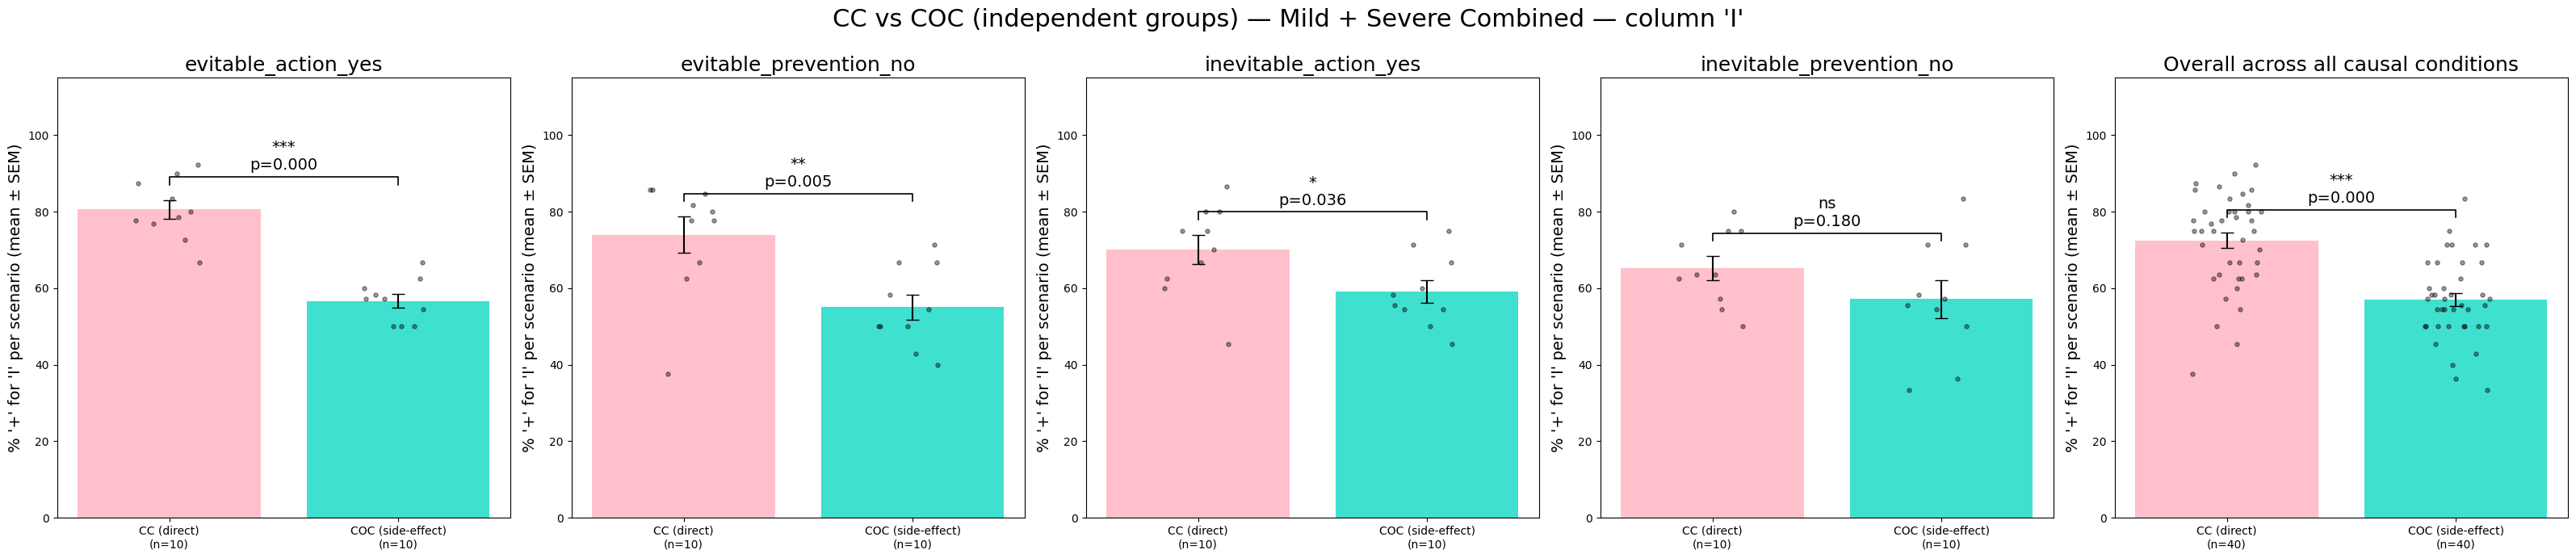

In [3]:
condition_pairs_cc_coc = [
    ("cc_evitable_action_yes_stories",    "coc_evitable_action_yes_stories",    "evitable_action_yes"),
    ("cc_evitable_prevention_no_stories", "coc_evitable_prevention_no_stories", "evitable_prevention_no"),
    ("cc_inevitable_action_yes_stories",  "coc_inevitable_action_yes_stories",  "inevitable_action_yes"),
    ("cc_inevitable_prevention_no_stories","coc_inevitable_prevention_no_stories","inevitable_prevention_no"),
]

panel_vals = []
all_vals_a, all_vals_b = [], []
for cond_a, cond_b, panel_title in condition_pairs_cc_coc:
    vals_a = per_scenario_proportion(all_FRANKEN_df, cond_a, "I").values * 100
    vals_b = per_scenario_proportion(all_FRANKEN_df, cond_b, "I").values * 100
    panel_vals.append((vals_a, vals_b, panel_title))
    all_vals_a.extend(vals_a)
    all_vals_b.extend(vals_b)
panel_vals.append((np.array(all_vals_a), np.array(all_vals_b), "Overall across all causal conditions"))

fig, axs = plt.subplots(1, 5, figsize=(32, 7))
for ax, (vals_a, vals_b, panel_title) in zip(axs, panel_vals):
    p_val = ttest_ind(vals_a, vals_b, equal_var=False).pvalue
    means, sems, n = bar_dot_sem(ax, {"CC (direct)": vals_a, "COC (side-effect)": vals_b}, colors=["pink", "turquoise"])
    y_top = max(m + s for m, s in zip(means, sems)) + 4
    ax.plot([0, 0, 1, 1], [y_top, y_top + 2, y_top + 2, y_top], lw=1.2, c="black")
    ax.text(0.5, y_top + 3, f"{sig_stars(p_val)}\np={p_val:.3f}", ha="center", va="bottom", fontsize=14)
    ax.set_ylim(0, 115)
    ax.set_ylabel("% '+' for 'I' per scenario (mean ± SEM)")
    ax.yaxis.label.set_size(14)
    ax.set_title(panel_title, fontsize=18)

    print(f"[{panel_title}] CC n={len(vals_a)} mean={np.mean(vals_a):.1f}%, COC n={len(vals_b)} mean={np.mean(vals_b):.1f}%, Welch's t-test p={p_val:.4f}")

plt.suptitle("CC vs COC (independent groups) — Mild + Severe Combined — column 'I'", fontsize=22)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

### **RESULT:** Hypothesis is true -- CC (mean-sharm) scenarios generate more I+ (intentional) events compared to COC.

## Analysis 1B -- Comparing *across* the CC and COC groups of scenarios; which group has more scenarios where the primary harm event is labelled I+?

### **Hypothesis:** The CC group of scenarios should have more scenarios where the primary harm event is labelled I+ compared to COC

[evitable_action_yes] CC I+ 4/10 (40.0%), COC I+ 0/10 (0.0%), Fisher's exact p=0.0867
[evitable_prevention_no] CC I+ 6/10 (60.0%), COC I+ 0/10 (0.0%), Fisher's exact p=0.0108
[inevitable_action_yes] CC I+ 1/10 (10.0%), COC I+ 0/10 (0.0%), Fisher's exact p=1.0000
[inevitable_prevention_no] CC I+ 2/10 (20.0%), COC I+ 1/10 (10.0%), Fisher's exact p=1.0000
[Overall across all causal conditions] CC I+ 13/40 (32.5%), COC I+ 1/40 (2.6%), Fisher's exact p=0.0007


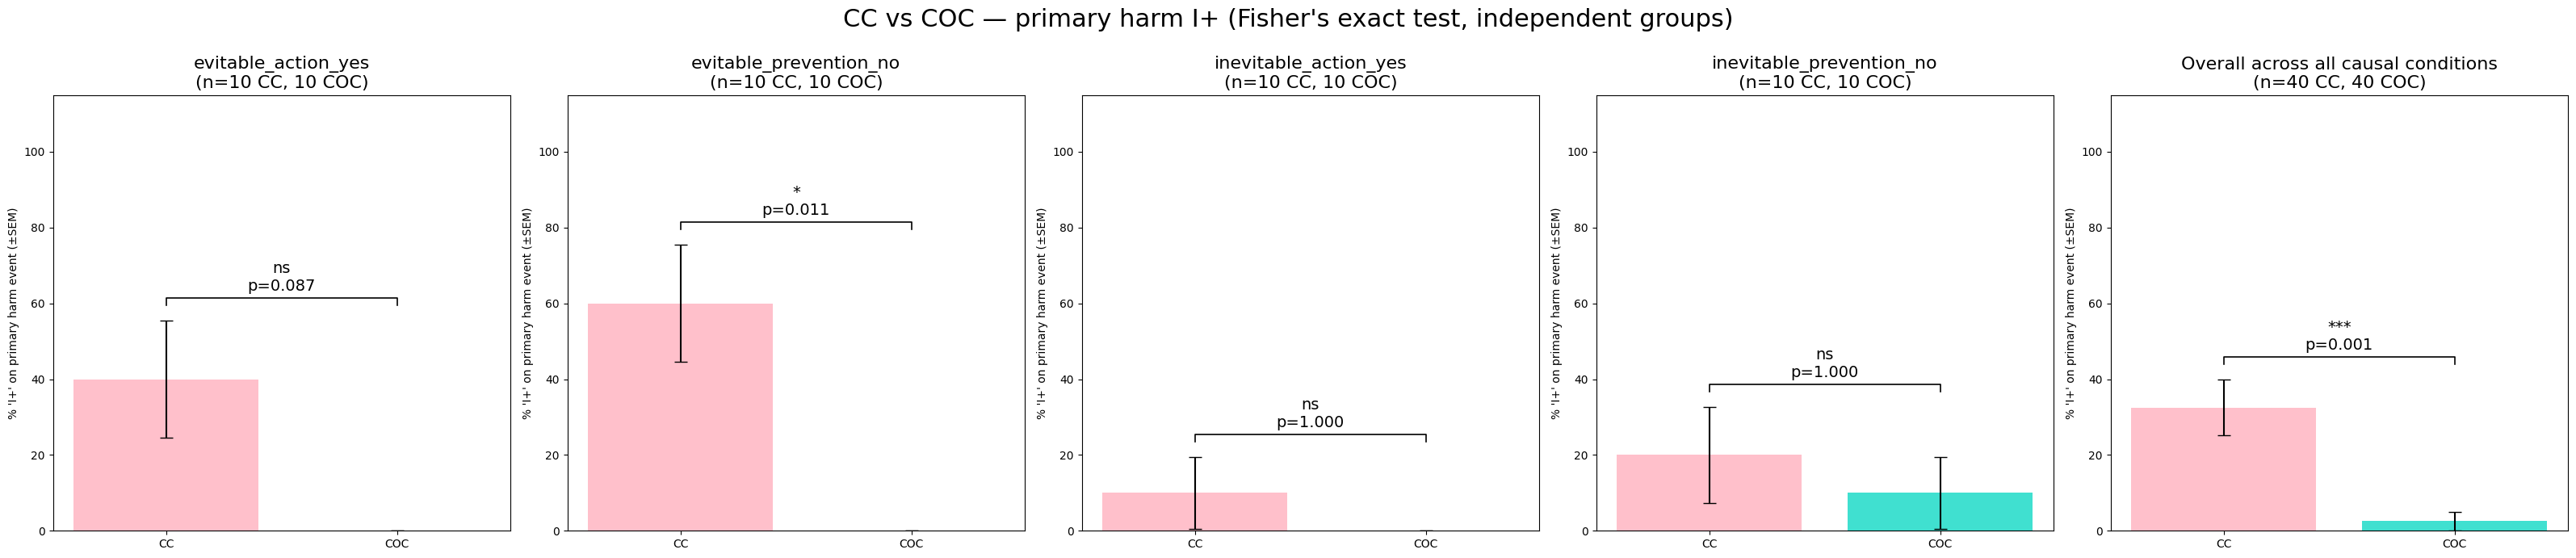

In [4]:
### Analysis 1B -- I+/- on primary harm event: CC vs COC (Fisher's exact test, independent groups), broken down into the same 4 evitability x action sub-panels + overall as Analysis 1A, for visual consistency -- only the "Overall" panel is really informative here since each sub-panel only has n=10 scenarios per group.
# NOTE: CC and COC scenarios sharing the same SID share a profession/persona but are otherwise
# independently-written dilemmas (e.g. SID 0 is "park renovation" for CC vs "bike lane system" for
# COC, but both are an architect) -- unlike the evitable/inevitable and action/prevention comparisons (Analyses 2/3), where the
# SAME dilemma is literally reused, just re-narrated with "I" vs "my colleague". So CC and COC are
# treated here as independent groups and compared with Fisher's exact test rather than a paired test.

primary_harm_df = pd.read_csv("mild_FRANKEN_primary_harm_df.csv")

primary_harm_df["structure"] = np.where(primary_harm_df["causal_condition"].str.startswith("cc"), "cc", "coc")
# NOTE: check "inevitable" first, it's a substring of "evitable"'s complement here so order matters
primary_harm_df["evitability"] = np.where(primary_harm_df["causal_condition"].str.contains("inevitable"), "inevitable", "evitable")
primary_harm_df["action"] = np.where(primary_harm_df["causal_condition"].str.contains("action_yes"), "action_yes", "prevention_no")
primary_harm_df["I_binary"] = primary_harm_df["I"].map({"+": 1, "-": 0})

subgroup_defs_1b = [
    ("evitable", "action_yes", "evitable_action_yes"),
    ("evitable", "prevention_no", "evitable_prevention_no"),
    ("inevitable", "action_yes", "inevitable_action_yes"),
    ("inevitable", "prevention_no", "inevitable_prevention_no"),
]

panel_data_1b = [(primary_harm_df[(primary_harm_df["evitability"] == evit) & (primary_harm_df["action"] == action)], title)
                  for evit, action, title in subgroup_defs_1b]
panel_data_1b.append((primary_harm_df, "Overall across all causal conditions"))

fig, axs = plt.subplots(1, 5, figsize=(32, 7))
for ax, (sub, panel_title) in zip(axs, panel_data_1b):
    cc_sub  = sub[sub["structure"] == "cc"]
    coc_sub = sub[sub["structure"] == "coc"]
    n_cc, n_coc = len(cc_sub), len(coc_sub)
    cc_pct, coc_pct = 100 * cc_sub["I_binary"].mean(), 100 * coc_sub["I_binary"].mean()

    table = [[n_cc - cc_sub["I_binary"].sum(), cc_sub["I_binary"].sum()],
             [n_coc - coc_sub["I_binary"].sum(), coc_sub["I_binary"].sum()]]
    _, p_val = fisher_exact(table)

    pcts = [cc_pct, coc_pct]
    sems = [100 * np.sqrt((p / 100) * (1 - p / 100) / n) for p, n in zip(pcts, [n_cc, n_coc])]
    ax.bar(["CC", "COC"], pcts, yerr=sems, capsize=6, color=["pink", "turquoise"], error_kw=dict(elinewidth=1.5))
    y_top = max(p + s for p, s in zip(pcts, sems)) + 4
    ax.plot([0, 0, 1, 1], [y_top, y_top + 2, y_top + 2, y_top], lw=1.2, c="black")
    ax.text(0.5, y_top + 3, f"{sig_stars(p_val)}\np={p_val:.3f}", ha="center", va="bottom", fontsize=14)
    ax.set_ylim(0, 115)
    ax.set_ylabel("% 'I+' on primary harm event (±SEM)")
    ax.set_title(f"{panel_title}\n(n={n_cc} CC, {n_coc} COC)", fontsize=16)

    print(f"[{panel_title}] CC I+ {int(cc_sub['I_binary'].sum())}/{n_cc} ({cc_pct:.1f}%), COC I+ {int(coc_sub['I_binary'].sum())}/{n_coc} ({coc_pct:.1f}%), Fisher's exact p={p_val:.4f}")

plt.suptitle("CC vs COC — primary harm I+ (Fisher's exact test, independent groups)", fontsize=22)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

### **RESULT:** Hypothesis is true -- 13/40 CC scenarios have the primary harm event labelled I+, and only 1/40 COC scenarios has the primary harm event labelled I+.

## Analysis 1C -- Do the human intentionality ratings differ between CC and COC scenarios?

### Human `avg_intention_rating` comes from Exp2 (1-5 scale). CC and COC scenarios are treated as independent groups here (see Analysis 1B's note on why), comparing only the causal-structure manipulation (CC vs COC) directly.

### **Hypothesis:** The CC scenarios should have gotten higher intentionality ratings compared to COC

[evitable_action_yes] CC mean=2.600 (n=10), COC mean=2.287 (n=10), t=2.603, p=0.0181
[evitable_prevention_no] CC mean=2.381 (n=10), COC mean=2.202 (n=10), t=1.865, p=0.0789
[inevitable_action_yes] CC mean=2.062 (n=10), COC mean=1.920 (n=10), t=1.315, p=0.2049
[inevitable_prevention_no] CC mean=2.146 (n=10), COC mean=1.992 (n=10), t=1.667, p=0.1204
[Overall across all causal conditions] CC mean=2.297 (n=40), COC mean=2.100 (n=40), t=3.025, p=0.0034


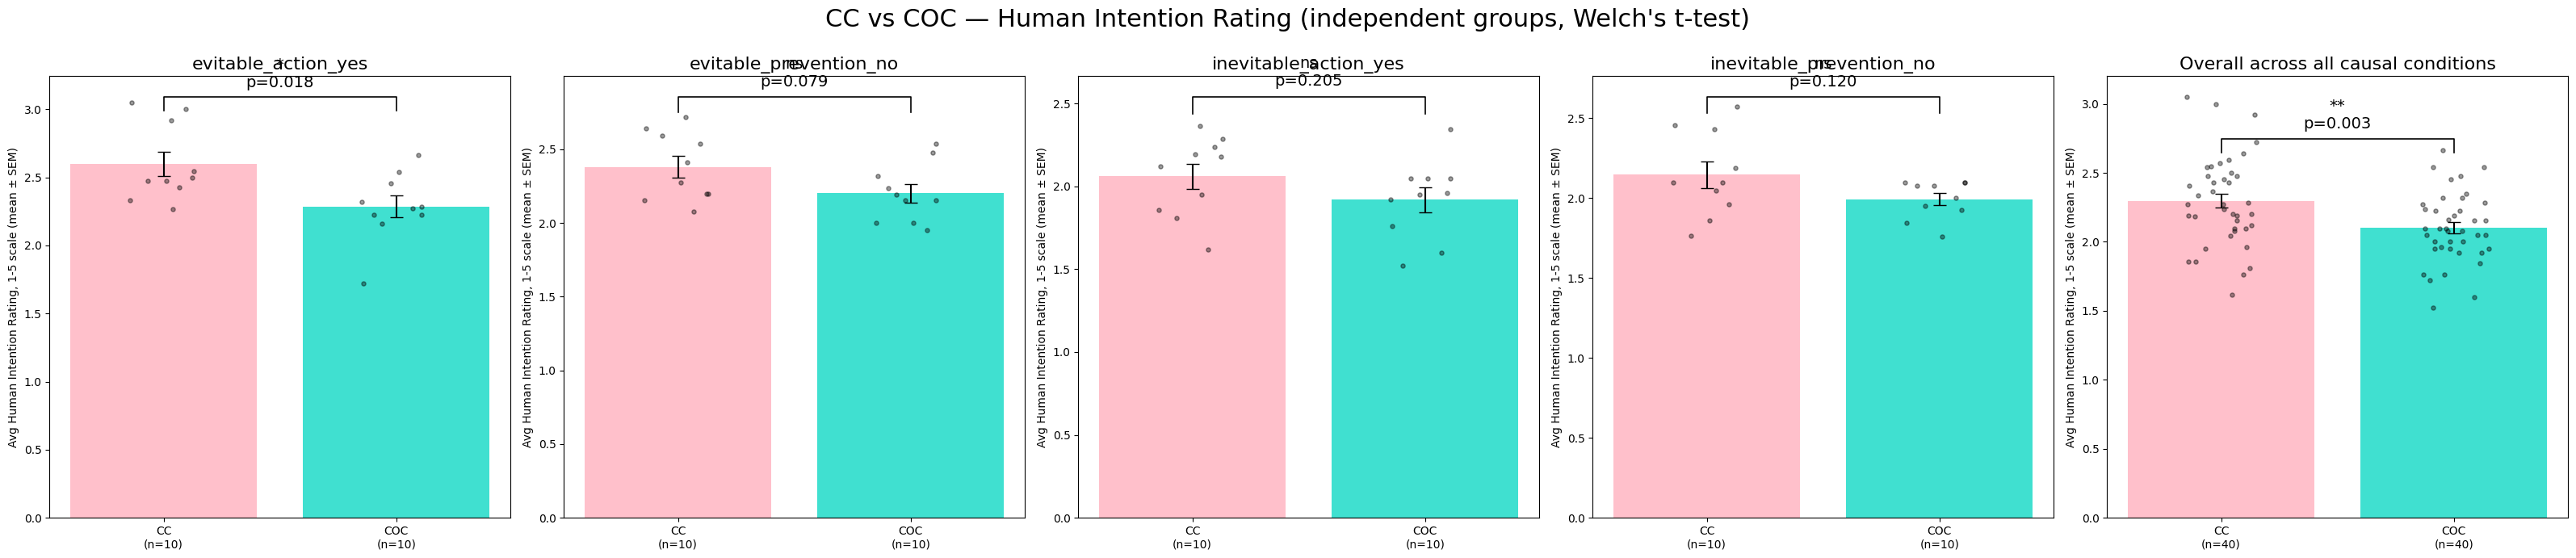

In [5]:
### Analysis 1C -- Human intention rating: CC vs COC (independent groups, Welch's t-test), broken down into the same 4 evitability x action sub-panels + overall as Analysis 1A, for visual consistency -- only the "Overall" panel is really informative here since each sub-panel only has n=10 scenarios per group.

# Load and average human ratings
human_ratings_raw = pd.read_csv(Path().resolve() / "../../human_data/franken/exp2_moralperm-intent-rating/data_long_format.csv")
avg_int = (human_ratings_raw
           .groupby(["scenario_id", "causal_structure", "evitability", "action"])["intention_rating"]
           .mean().reset_index()
           .rename(columns={"intention_rating": "avg_intention_rating"}))

# BUG FIX:
cc_ratings  = avg_int[avg_int["causal_structure"] == 1]
coc_ratings = avg_int[avg_int["causal_structure"] == 0]

# evitability/action here are numeric (0/1) per (0=inevitable/omission, 1=evitable/commission)
subgroup_defs_1c = [
    (1, 1, "evitable_action_yes"),
    (1, 0, "evitable_prevention_no"),
    (0, 1, "inevitable_action_yes"),
    (0, 0, "inevitable_prevention_no"),
]

panel_data_1c = [(cc_ratings[(cc_ratings["evitability"] == evit) & (cc_ratings["action"] == action)]["avg_intention_rating"].values,
                   coc_ratings[(coc_ratings["evitability"] == evit) & (coc_ratings["action"] == action)]["avg_intention_rating"].values,
                   title)
                  for evit, action, title in subgroup_defs_1c]
panel_data_1c.append((cc_ratings["avg_intention_rating"].values, coc_ratings["avg_intention_rating"].values, "Overall across all causal conditions"))

fig, axs = plt.subplots(1, 5, figsize=(32, 7))
for ax, (cc_vals, coc_vals, panel_title) in zip(axs, panel_data_1c):
    n_cc, n_coc = len(cc_vals), len(coc_vals)
    t_stat, p_val = ttest_ind(cc_vals, coc_vals, equal_var=False)
    means, sems, _ = bar_dot_sem(ax, {"CC": cc_vals, "COC": coc_vals}, colors=["pink", "turquoise"])
    y_top = max(m + s for m, s in zip(means, sems)) + 0.3
    ax.plot([0, 0, 1, 1], [y_top, y_top + 0.1, y_top + 0.1, y_top], lw=1.2, c="black")
    ax.text(0.5, y_top + 0.15, f"{sig_stars(p_val)}\np={p_val:.3f}", ha="center", va="bottom", fontsize=14)
    ax.set_ylabel("Avg Human Intention Rating, 1-5 scale (mean ± SEM)")
    ax.set_title(f"{panel_title}", fontsize=16)

    print(f"[{panel_title}] CC mean={np.mean(cc_vals):.3f} (n={n_cc}), COC mean={np.mean(coc_vals):.3f} (n={n_coc}), t={t_stat:.3f}, p={p_val:.4f}")

plt.suptitle("CC vs COC — Human Intention Rating (independent groups, Welch's t-test)", fontsize=22)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

### **RESULT (corrected):** Hypothesis is true -- CC (means) scenarios get significantly higher human intentionality ratings than COC (side-effect) scenarios.

# Analysis 2 -- Do "evitable" scenarios generate more causal events than "inevitable" scenarios?
### Comparing the per-scenario proportion of "C+" events between Evitable and Inevitable counterparts of the causal conditions (also checking overall across all)
### **Commonsense hypothesis =** Evitable scenarios should have more events with more "control" over the outcome than inevitable, i.e. get more C+'s than inevitable scenarios.

### Same scenario-level, paired-by-SID improvement as Analysis 1 (paired here by SID x causal_structure x action, varying only evitability).

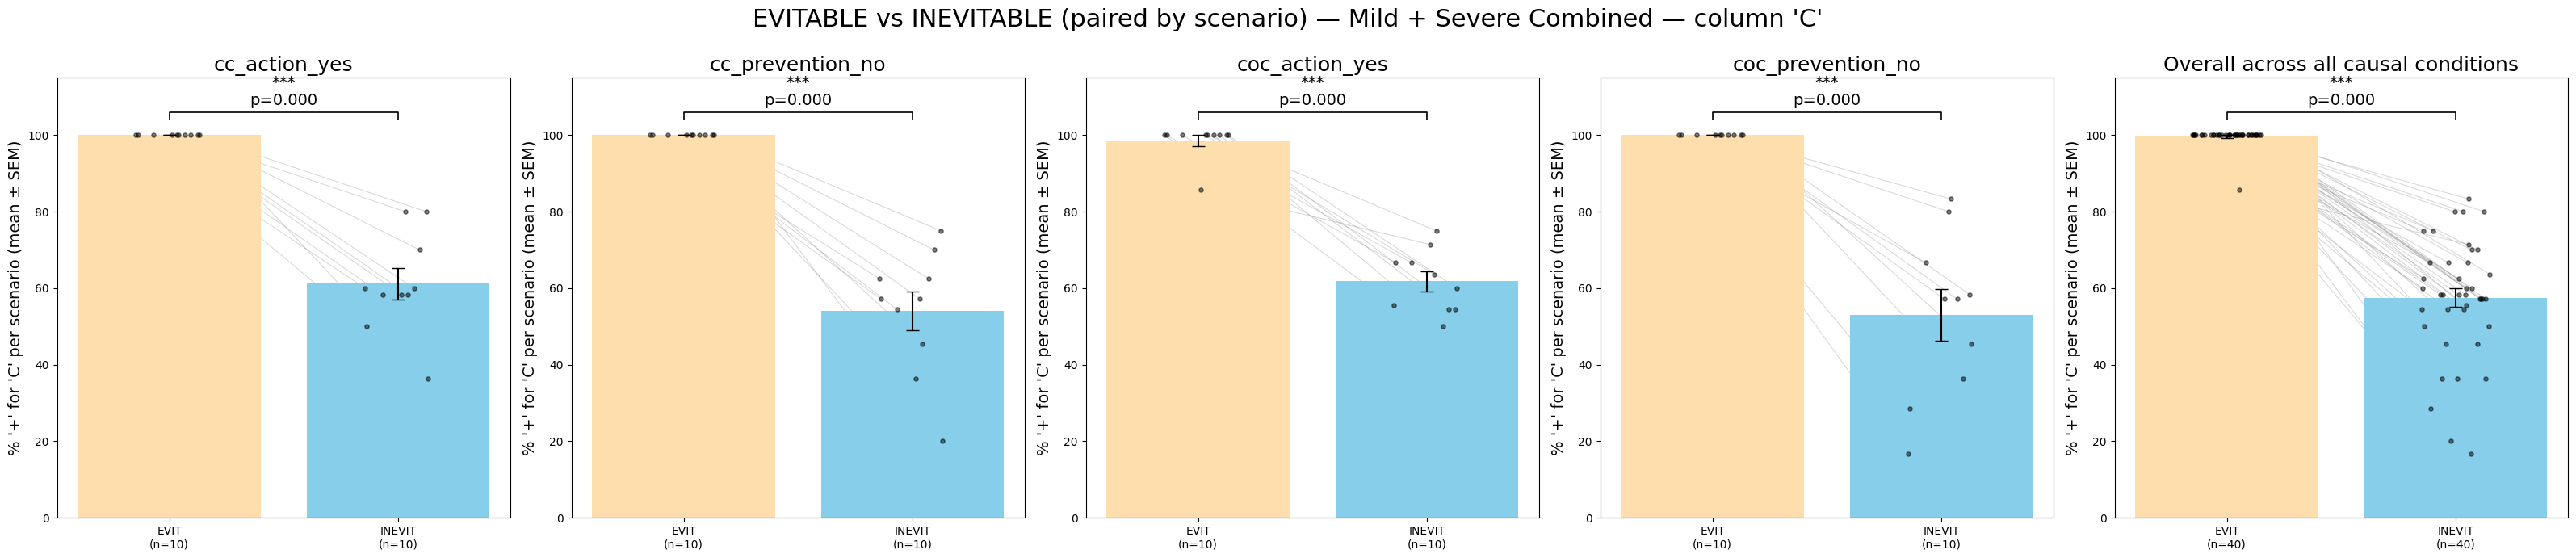

In [6]:
condition_pairs_evit_inevit = [
    ("cc_evitable_action_yes_stories",     "cc_inevitable_action_yes_stories",     "cc_action_yes"),
    ("cc_evitable_prevention_no_stories",  "cc_inevitable_prevention_no_stories",  "cc_prevention_no"),
    ("coc_evitable_action_yes_stories",    "coc_inevitable_action_yes_stories",    "coc_action_yes"),
    ("coc_evitable_prevention_no_stories", "coc_inevitable_prevention_no_stories", "coc_prevention_no"),
]

paired_proportion_barplots(all_FRANKEN_df, "Mild + Severe Combined", column="C",
                            condition_pairs=condition_pairs_evit_inevit, pair_labels=("EVIT", "INEVIT"),
                            colors=["navajowhite", "skyblue"],
                            suptitle="EVITABLE vs INEVITABLE (paired by scenario) — Mild + Severe Combined — column 'C'")

### **RESULT:** Hypothesis is true -- Evitable scenarios generate more C+ (causal) events compared to inevitable scenarios.

# Analysis 3 -- Do "commission" scenarios generate more intentional events than "omission" scenarios?
### Comparing the per-scenario proportion of "I+" events between action_yes (commission) and prevention_no (omission) counterparts of the causal conditions (also checking overall across all)
### **Commonsense hypothesis =** Explicitly acting towards a harm feels more intentional than letting it happen passively, so they should get more I+ events.

### Same scenario-level, paired-by-SID improvement as Analyses 1 and 2 (paired here by SID x causal_structure x evitability, varying only action).

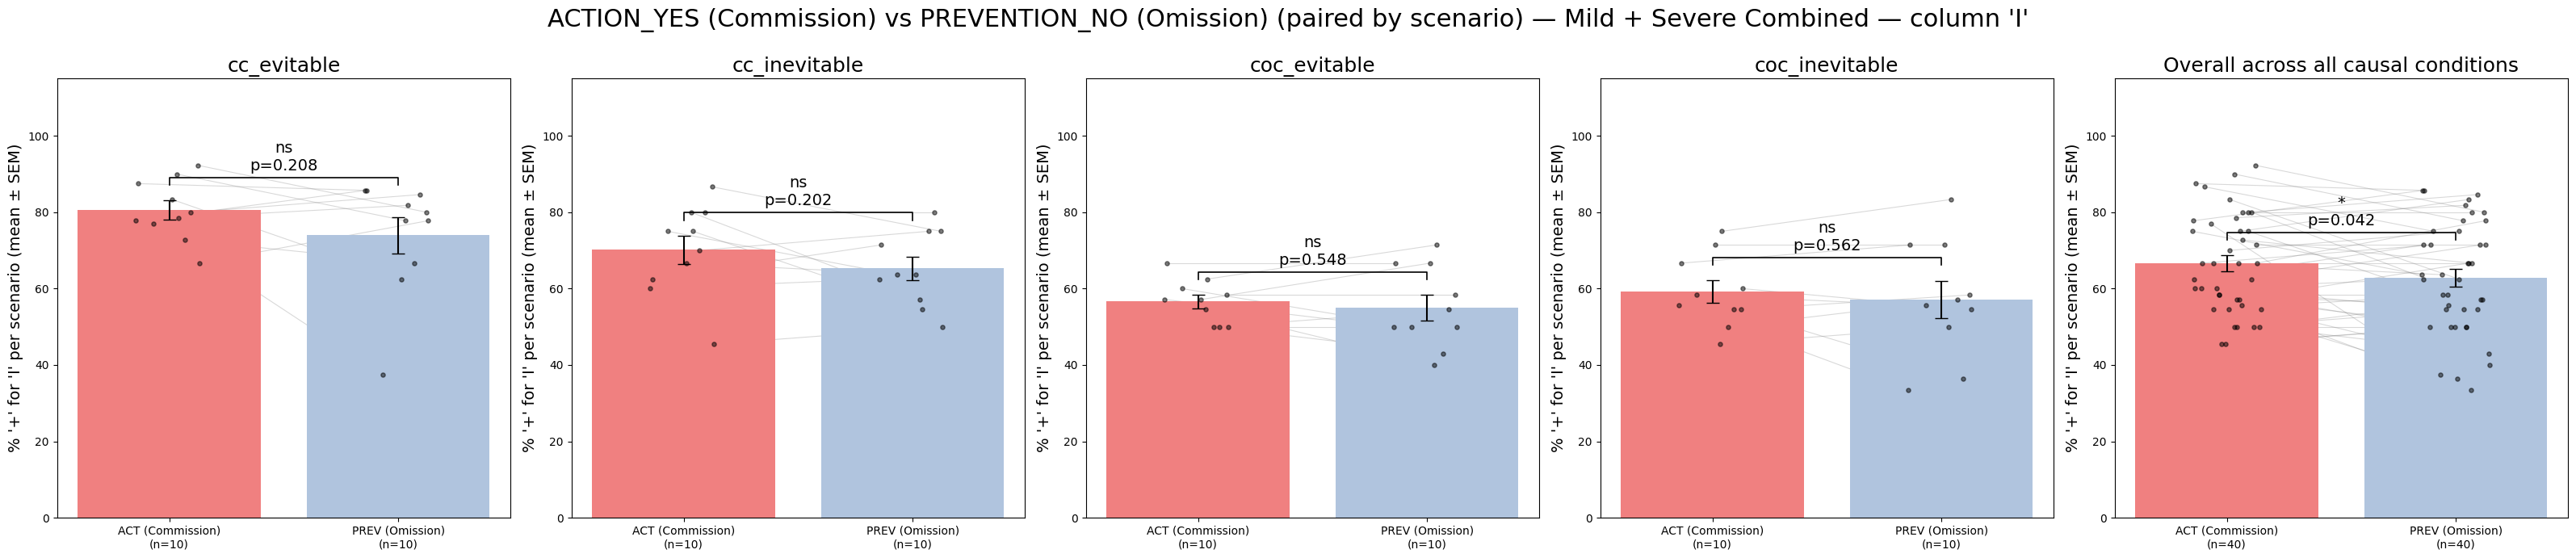

In [7]:
condition_pairs_action_prevention = [
    ("cc_evitable_action_yes_stories",    "cc_evitable_prevention_no_stories",    "cc_evitable"),
    ("cc_inevitable_action_yes_stories",  "cc_inevitable_prevention_no_stories",  "cc_inevitable"),
    ("coc_evitable_action_yes_stories",   "coc_evitable_prevention_no_stories",   "coc_evitable"),
    ("coc_inevitable_action_yes_stories", "coc_inevitable_prevention_no_stories", "coc_inevitable"),
]

paired_proportion_barplots(all_FRANKEN_df, "Mild + Severe Combined", column="I",
                            condition_pairs=condition_pairs_action_prevention, pair_labels=("ACT (Commission)", "PREV (Omission)"),
                            colors=["lightcoral", "lightsteelblue"],
                            suptitle="ACTION_YES (Commission) vs PREVENTION_NO (Omission) (paired by scenario) — Mild + Severe Combined — column 'I'")

### **RESULT:** Hypothesis is not true -- there is not a significant difference in proportion of I+ events generated between ACT (comission) and PREV (omission) scenarios.

# Analysis 4 -- Do "severe" scenarios get events with more extreme utility scores than "mild" scenarios?
### Comparing the utility score distributions between mild and severe counterparts of each causal condition (also checking overall)
### **Commonsense hypothesis =** The "severe_harm_very_good" utility distributions SHOULD be more negative (on the harm side) AND more positive (on the good side) overall than the "mild_harm_mild_good" utility distributions.

#### **How do we pick one utility score to represent a scenario?**
##### A scenario has several generated events, and each event has its own utility score per identified entity (agent + any bystanders/patients). Reducing all of that down to one number per scenario is two independent choices:

1. ##### **Which entities count** -- the `UTILITY_PICK_STRATEGY` flag in the next cell:
    - ##### **`simplest`** -- everyone (the agent "i" and every other identified entity)
    - ##### **`i_only`** -- just the agent "i"
    - ##### **`non_i_only`** -- everyone except "i", i.e. all patients/bystanders, undifferentiated

2. ##### **How to reduce the pool to one number** -- `UTILITY_AGG_FUNC` in the next cell. Every value from every entity selected above, across every event of the scenario, is pooled into one flat list first (entities are never treated specially relative to each other or to other events once step 1 has picked which ones count) -- then that pool is reduced with:
    - ##### **`min`** -- most-negative value in the pool ("primary harm" magnitude -- peak severity)
    - ##### **`max`** -- most-positive value in the pool ("primary good" magnitude -- peak severity)
    - ##### **`np.mean`** -- average across everything in the pool (overall/average tone, rather than the single worst/best moment)

##### Change both flags in the next cell.

In [8]:
# Two independent choices for turning a scenario's per-event, per-entity utility scores into one
# number (see markdown above): which entities count (UTILITY_PICK_STRATEGY), and how the resulting
# pool of values gets reduced to a single number (UTILITY_AGG_FUNC). Both are used by every
# downstream analysis that calls _reduce_to_per_scenario (Analysis 4 only, now that 5B is gone).

# "simplest"    -- everyone (agent + bystanders)
# "i_only"      -- just the agent "i"
# "non_i_only"  -- everyone except "i" (all patients/bystanders, undifferentiated)
analysis_ntbk_helpers.UTILITY_PICK_STRATEGY = "non_i_only"

# min      -- most-negative pooled value (peak harm severity -- pair with alternative="less" below)
# max      -- most-positive pooled value (peak good severity -- pair with alternative="greater" below)
# np.mean  -- average across the whole pool (overall tone, not just the peak)
UTILITY_AGG_FUNC = np.mean

# THIS WILL AFFECT ANALYSIS 4 ONLY.

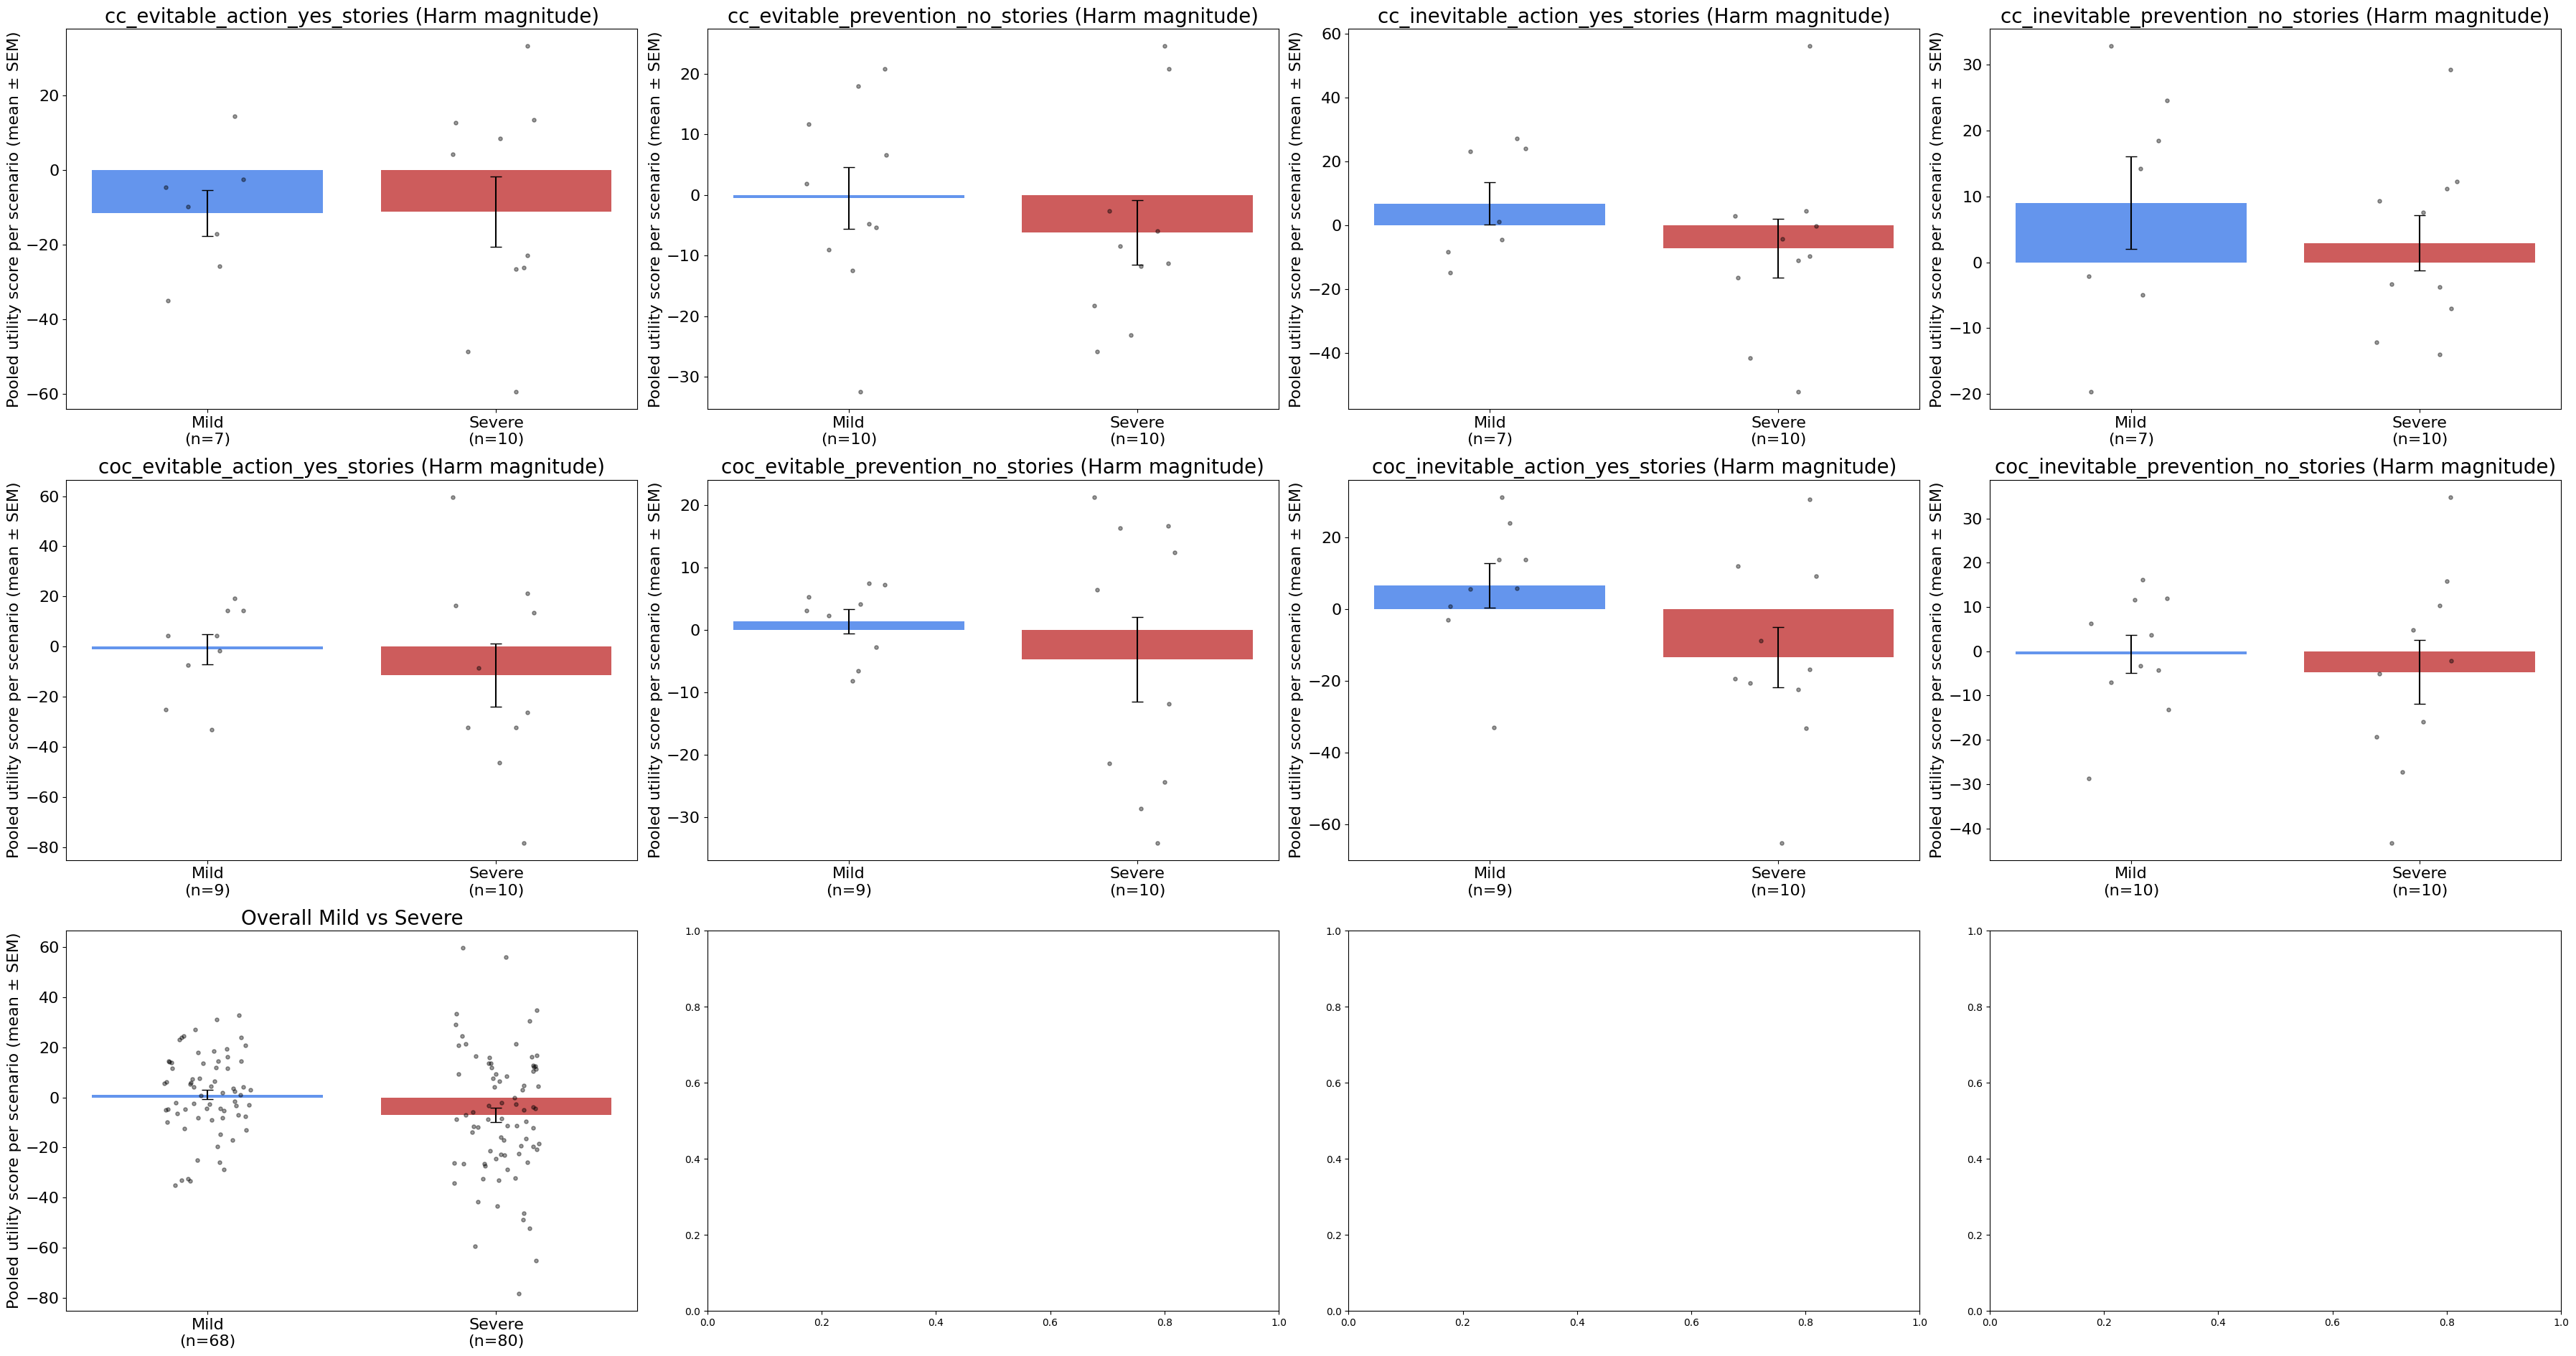

In [9]:
create_utility_bar_dot_plots(all_FRANKEN_df, "(Harm magnitude)", UTILITY_AGG_FUNC, "Pooled utility score per scenario (mean ± SEM)")

### **RESULT:**

- ### The utility scores look more negative-shifted in general for severe scenarios in general.

- ### This tell us that the "severe" scenarios' worst scores are more negative than "mild" scenarios' worst scores. (So "severe_harm" is indeed more severe than "mild_harm"). 

- ### Is "_very_good" indeed more good than "_mild_good" though? We don't know that part. We could know if we compared the most positive event utility scores b/w severe and mild scenarios instead (which would be the opposite of a primary harm), but it doesn't really matter as a thing to check. I suspect it is true.

### Is the severe utility distribution **statistically significantly** more negative (harm) than the mild distribution? One-sided t-tests across the 9 tests (8 causal conditions + overall) within each of the two utility directions:

In [10]:
print("Harm magnitude (pooled utility, UTILITY_AGG_FUNC applied): one-sided test that severe < mild, across 9 tests:")
harm_t_test_results = perform_t_tests(all_FRANKEN_df, UTILITY_AGG_FUNC, alternative="less")
pprint.pprint(harm_t_test_results)

Harm magnitude (pooled utility, UTILITY_AGG_FUNC applied): one-sided test that severe < mild, across 9 tests:
{'cc_evitable_action_yes_stories': {'p_value': np.float64(0.5105129965328534),
                                    't_stat': np.float64(0.026798149512511065)},
 'cc_evitable_prevention_no_stories': {'p_value': np.float64(0.22404020188590207),
                                       't_stat': np.float64(-0.7755578701501733)},
 'cc_inevitable_action_yes_stories': {'p_value': np.float64(0.13723754941119465),
                                      't_stat': np.float64(-1.1342909801220513)},
 'cc_inevitable_prevention_no_stories': {'p_value': np.float64(0.22088878339784443),
                                         't_stat': np.float64(-0.7901074240519581)},
 'coc_evitable_action_yes_stories': {'p_value': np.float64(0.2466574470572678),
                                     't_stat': np.float64(-0.7001335523041097)},
 'coc_evitable_prevention_no_stories': {'p_value': np.float64(0.21166

### Note: t-stat being negative means that severe scores are indeed more negative than mild.

### **RESULT:** The severe utility score distributions are (basically) always statistically significantly more negative than mild counterpart -- there is a consistent diference in utility score distribution between severe and mild scenarios

# Analysis 5 -- Do scenarios deemed more intentional by the annotator (in some way) get rated as more intentional by humans too?

### Humans rated intentionality on a SCENARIO-level, annotator gives "I" labels on an EVENT-level. 

### We split the scenarios into I+ and I- groups based on the HAND-PICKED HARM EVENT (stored in `mild_FRANKEN_primary_harm_df.csv`) and compare the avg human intentionality rating given to each group -- we would like to see a significant difference in avg. human rating between the two.

Qualitative pick DF: 79 rows | I+: 14, I-: 65


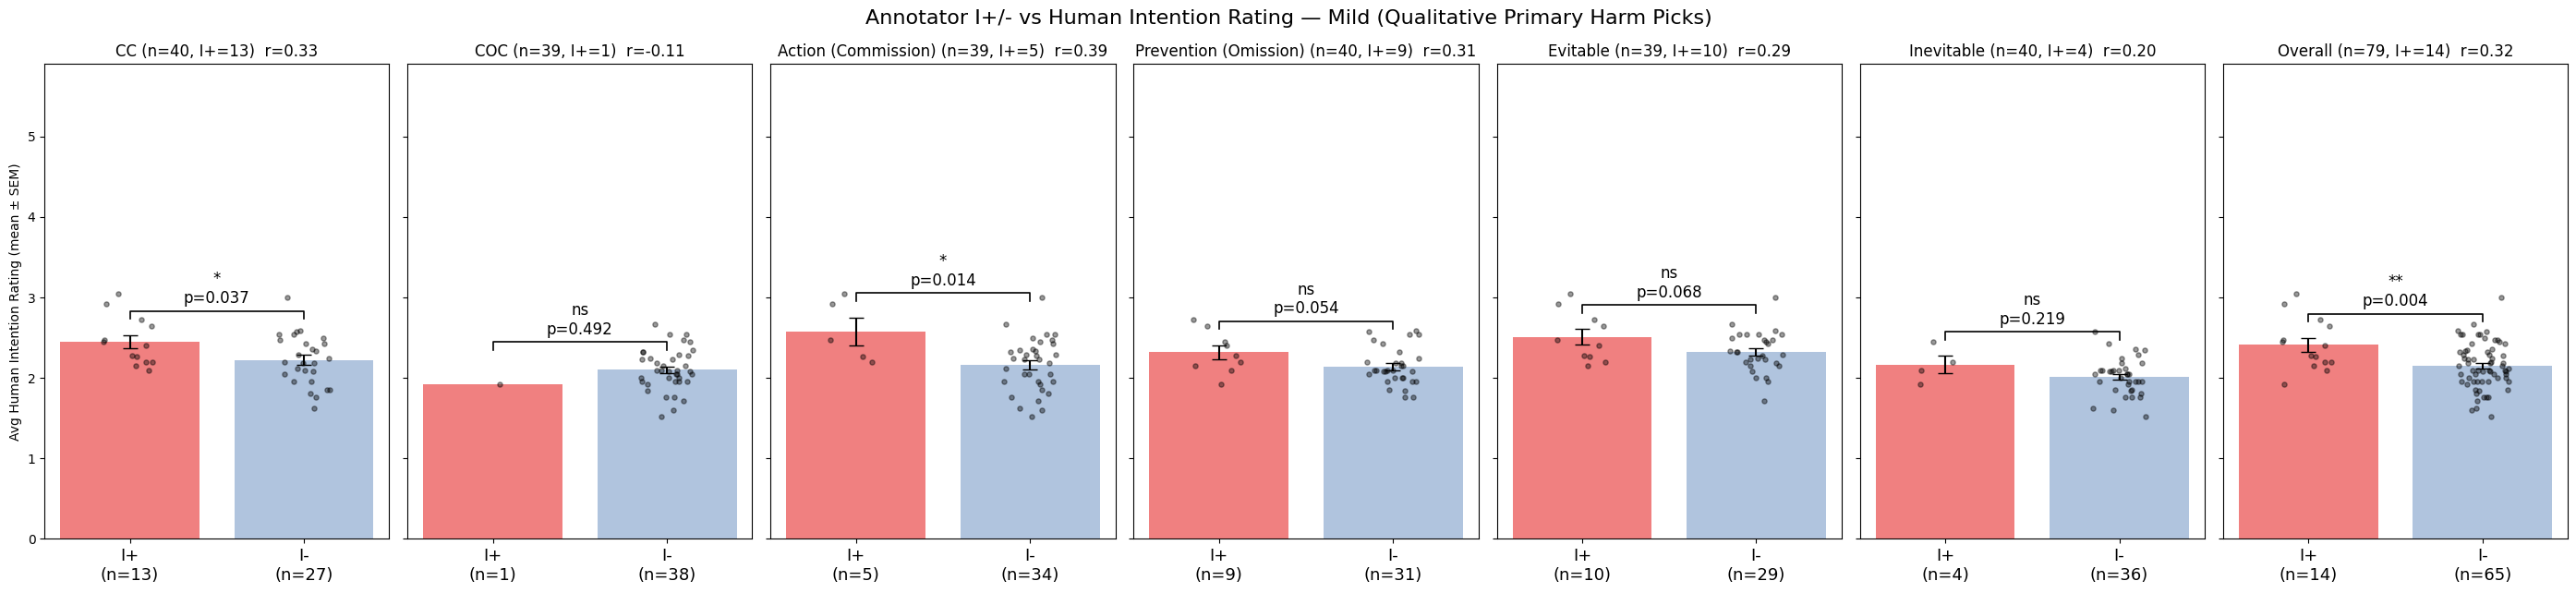

Correlation results — qualitative primary harm picks:
{'Action (Commission)': {'n_I+': 5,
                         'n_scenarios': 39,
                         'p_I_intention': 0.014319884662191366,
                         'r_I_intention (point-biserial)': 0.3892353200444169},
 'CC': {'n_I+': 13,
        'n_scenarios': 40,
        'p_I_intention': 0.03687144861807013,
        'r_I_intention (point-biserial)': 0.33113861320331806},
 'COC': {'n_I+': 1,
         'n_scenarios': 39,
         'p_I_intention': 0.49219791899335047,
         'r_I_intention (point-biserial)': -0.11331036968568535},
 'Evitable': {'n_I+': 10,
              'n_scenarios': 39,
              'p_I_intention': 0.06845779965365771,
              'r_I_intention (point-biserial)': 0.2948198964491612},
 'Inevitable': {'n_I+': 4,
                'n_scenarios': 40,
                'p_I_intention': 0.21909736346180342,
                'r_I_intention (point-biserial)': 0.1986669950989313},
 'Overall': {'n_I+': 14,
            

In [11]:
import ast

# mild_FRANKEN_primary_harm_df.csv already has the picked event's I, utility, and
# avg_intention_rating as scalar values -- load directly, no withhuman_df lookup needed
qualitative_scenario_df = pd.read_csv("mild_FRANKEN_primary_harm_df.csv").dropna()
qualitative_scenario_df["I_binary"] = qualitative_scenario_df["I"].map({"+": 1, "-": 0})
qualitative_scenario_df["I_label"]  = qualitative_scenario_df["I"].map({"+": "I+", "-": "I-"})

print(f"Qualitative pick DF: {len(qualitative_scenario_df)} rows | "
      f"I+: {(qualitative_scenario_df['I'] == '+').sum()}, I-: {(qualitative_scenario_df['I'] == '-').sum()}")

correlation_results_qualitative = intentionality_by_I_label_plot(
    qualitative_scenario_df,
    suptitle="Annotator I+/- vs Human Intention Rating — Mild (Qualitative Primary Harm Picks)",
    print_label="qualitative primary harm picks",
)

### **RESULT (corrected):** Annotator I+/- labelling on the qualitatively-picked primary harm event now DOES correlate significantly with human intentionality overall (r=0.32, p=0.003).

# Analysis 6 -- Does Exp2 permissibility rating correlate with Exp1 harm and good rating?
### Regressing Exp2's `avg_permissibility_rating` on Exp1's `avg_harm_rating` and `avg_good_rating` (n=40 scenarios with both ratings: mild, action_yes causal conditions only).
### **Commonsense hypothesis =** A worse harm should make the action less permissible, and a bigger benefit should make it more permissible -- i.e. `avg_permissibility_rating` should rise with both `avg_harm_rating` and `avg_good_rating` (both share the same 1-7 Likert scale where 7 = most good outcome).


Bivariate: permissibility vs avg_harm_rating: r=0.401, p=0.0104  *
Bivariate: permissibility vs avg_good_rating:  r=0.358, p=0.0235  *


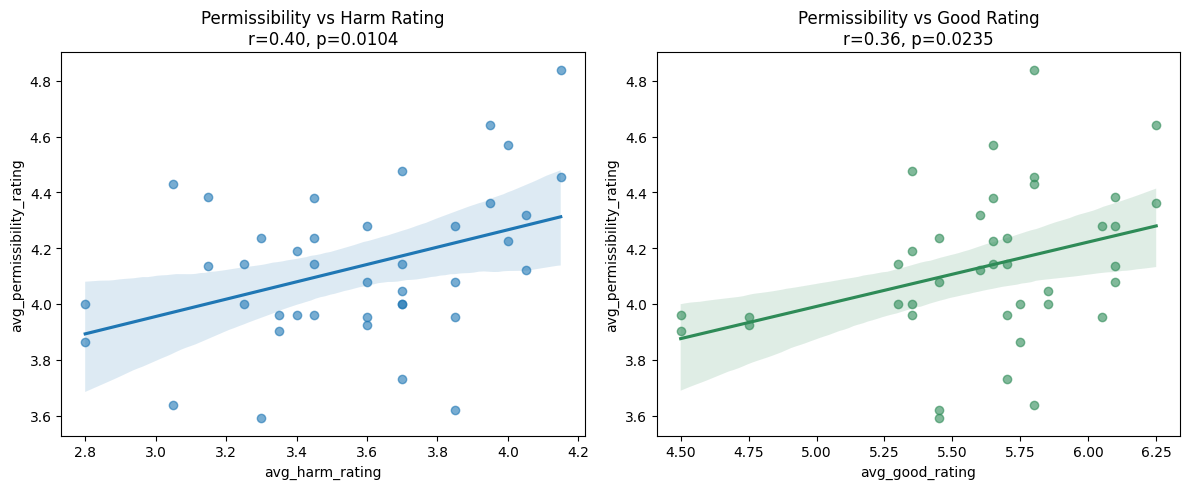

In [12]:
exp1exp2_df = pd.read_csv("all_FRANKEN_exp1exp2matched_df.csv")

r_harm, p_harm = pearsonr(exp1exp2_df["avg_harm_rating"], exp1exp2_df["avg_permissibility_rating"])
r_good, p_good = pearsonr(exp1exp2_df["avg_good_rating"], exp1exp2_df["avg_permissibility_rating"])
print(f"\nBivariate: permissibility vs avg_harm_rating: r={r_harm:.3f}, p={p_harm:.4f}  {sig_stars(p_harm)}")
print(f"Bivariate: permissibility vs avg_good_rating:  r={r_good:.3f}, p={p_good:.4f}  {sig_stars(p_good)}")

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
sns.regplot(data=exp1exp2_df, x="avg_harm_rating", y="avg_permissibility_rating", ax=axs[0], scatter_kws={"alpha": 0.6})
axs[0].set_title(f"Permissibility vs Harm Rating\nr={r_harm:.2f}, p={p_harm:.4f}")
sns.regplot(data=exp1exp2_df, x="avg_good_rating", y="avg_permissibility_rating", ax=axs[1], scatter_kws={"alpha": 0.6}, color="seagreen")
axs[1].set_title(f"Permissibility vs Good Rating\nr={r_good:.2f}, p={p_good:.4f}")
plt.tight_layout()
plt.show()

### **RESULT (corrected):** Hypothesis is now supported -- both avg_harm_rating (r=0.40, p=0.010) and avg_good_rating (r=0.36, p=0.023) are significantly positively correlated with avg_permissibility_rating.